<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/exp3.new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     AWS IoT CORE - SMART WATER TANK MONITORING

Device Registration
----------------------------
Device ID   : WATER001
Device Name : Smart_Water_Level_Sensor
Registration: Successful
Authentication: Successful

Cloud Data Received
----------------------------
Device ID  Reading  Water Level (%)          Status
 WATER001        1               54          NORMAL
 WATER001        2               87          NORMAL
 WATER001        3               76          NORMAL
 WATER001        4               38          NORMAL
 WATER001        5               88          NORMAL
 WATER001        6               42          NORMAL
 WATER001        7               73          NORMAL
 WATER001        8               27 LOW WATER ALERT
 WATER001        9               21 LOW WATER ALERT
 WATER001       10              100          NORMAL

Cloud Analytics
----------------------------
Average Water Level : 60.6 %
Normal Readings     : 8
Low Level Alerts    : 2

Water Tank Alerts
------------------------

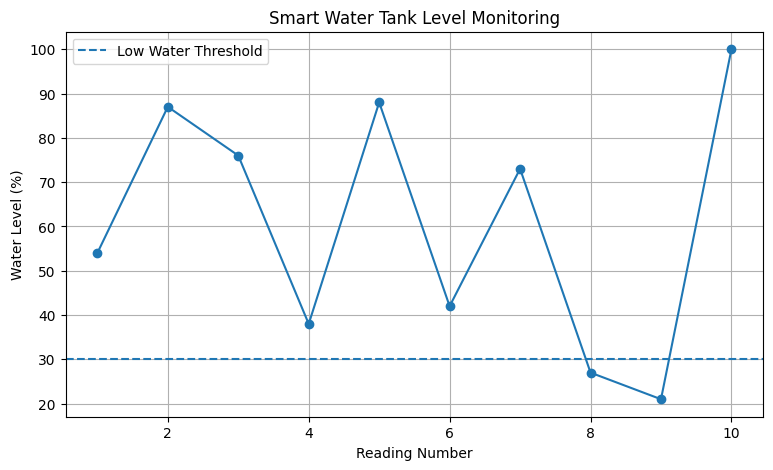


Cloud Data Saved Successfully
File: Smart_Water_Tank_Cloud_Data.csv

        AWS IoT CLOUD SIMULATION COMPLETED
Device Onboarding : Successful
Authentication    : Successful
Cloud Upload      : Successful
Cloud Analytics   : Completed
Alert Detection   : Completed
Data Storage      : Completed

Smart Water Tank Monitoring Completed Successfully!


In [1]:
# ============================================================
# EXPERIMENT No. 3
# Device Onboarding and Data Flow in AWS IoT Core
# Google Colab Simulation
# Scenario: Smart Water Tank Monitoring
# ============================================================

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("     AWS IoT CORE - SMART WATER TANK MONITORING")
print("=" * 60)

# ------------------------------------------------------------
# Device Registration
# ------------------------------------------------------------

device_id = "WATER001"
device_name = "Smart_Water_Level_Sensor"

print("\nDevice Registration")
print("----------------------------")
print("Device ID   :", device_id)
print("Device Name :", device_name)
print("Registration: Successful")

# ------------------------------------------------------------
# Device Authentication
# ------------------------------------------------------------

authentication = True

if authentication:
    print("Authentication: Successful")
else:
    print("Authentication: Failed")

# ------------------------------------------------------------
# Generate Water Tank Data
# ------------------------------------------------------------

water_levels = []

for i in range(1, 11):

    water_level = random.randint(20, 100)

    water_levels.append(water_level)

# ------------------------------------------------------------
# Cloud Data Processing
# ------------------------------------------------------------

records = []

for i in range(10):

    water_level = water_levels[i]

    if water_level < 30:
        status = "LOW WATER ALERT"
    else:
        status = "NORMAL"

    records.append([
        device_id,
        i + 1,
        water_level,
        status
    ])

# ------------------------------------------------------------
# Create Cloud Data Table
# ------------------------------------------------------------

df = pd.DataFrame(
    records,
    columns=[
        "Device ID",
        "Reading",
        "Water Level (%)",
        "Status"
    ]
)

print("\nCloud Data Received")
print("----------------------------")
print(df.to_string(index=False))

# ------------------------------------------------------------
# Cloud Analytics
# ------------------------------------------------------------

average_level = np.mean(water_levels)

low_level_count = len(
    df[df["Status"] == "LOW WATER ALERT"]
)

normal_count = len(
    df[df["Status"] == "NORMAL"]
)

print("\nCloud Analytics")
print("----------------------------")
print(
    "Average Water Level :",
    round(average_level, 2),
    "%"
)

print(
    "Normal Readings     :",
    normal_count
)

print(
    "Low Level Alerts    :",
    low_level_count
)

# ------------------------------------------------------------
# Alert Detection
# ------------------------------------------------------------

print("\nWater Tank Alerts")
print("----------------------------")

for i in range(len(df)):

    if df.loc[i, "Status"] == "LOW WATER ALERT":

        print(
            "Reading",
            df.loc[i, "Reading"],
            ": LOW WATER LEVEL ALERT -",
            df.loc[i, "Water Level (%)"],
            "%"
        )

# ------------------------------------------------------------
# Graph
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    df["Reading"],
    df["Water Level (%)"],
    marker="o"
)

# Low water threshold
plt.axhline(
    30,
    linestyle="--",
    label="Low Water Threshold"
)

plt.title("Smart Water Tank Level Monitoring")
plt.xlabel("Reading Number")
plt.ylabel("Water Level (%)")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Save Cloud Data
# ------------------------------------------------------------

df.to_csv(
    "Smart_Water_Tank_Cloud_Data.csv",
    index=False
)

print("\nCloud Data Saved Successfully")
print("File: Smart_Water_Tank_Cloud_Data.csv")

# ------------------------------------------------------------
# Final Result
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("        AWS IoT CLOUD SIMULATION COMPLETED")
print("=" * 60)

print("Device Onboarding : Successful")
print("Authentication    : Successful")
print("Cloud Upload      : Successful")
print("Cloud Analytics   : Completed")
print("Alert Detection   : Completed")
print("Data Storage      : Completed")

print("\nSmart Water Tank Monitoring Completed Successfully!")
print("=" * 60)